In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.isna().sum().sum()

np.int64(0)

In [6]:
le = LabelEncoder()
# encoding sentements
df['sentiment'] = le.fit_transform(df['sentiment'])

In [8]:
# integer tokenize the reviews
tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])
sequences = pad_sequences(sequences,padding='post',maxlen=500)
print(sequences[0])

[   27     4     1    79  2102    45  1072    12   100   147    39   307
  3184   398   474    26  3195    33    23   203    14    11     6   621
    48   596    16    68     7     7     1    86   148    12  3241    68
    42  3184    13    92  5398     2 15115   134     4   570    60   268
     8   203    36     1   661   139  1740    68    11     6    21     3
   119    15     1  7888  2333    38 11469    11   119  2595    54  5911
    16  5510     5  1479   376    38   570    92     6  3804     8     1
   360   356     4     1   661     7     7     9     6   433  3184    14
    12     6     1 11648   358     5     1 15701  6813  2538  1064 56309
     9  2711  1421    20 23546   538    32  4636  2468     4     1  1208
   117    29     1  7017    25  2970 11964     2   391 56310    34 16740
     6    21   299    20     1  4910  7364   538     6   344     5   106
 25421  8161 42636 14813  5050  7889  2453     2    51    34 48042   327
  9106  7365 12486     2  8697 33191    23   110   

In [9]:
# spliting data into feature and labels
X = sequences
y = df['sentiment']

# spliting in train and test set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
print("Shapes: ")
print("X_train: ",X_train.shape)
print("y_train: ",y_train.shape)
print("X_test : ",X_test.shape)
print("y_test : ",y_test.shape)

Shapes: 
X_train:  (40000, 500)
y_train:  (40000,)
X_test :  (10000, 500)
y_test :  (10000,)


In [11]:
X_train[:5]

array([[ 196,   48,   10, ...,    0,    0,    0],
       [  10,  115,   21, ...,    0,    0,    0],
       [   3, 1364,  112, ...,    0,    0,    0],
       [  11, 1601,  254, ...,    0,    0,    0],
       [  86,    4,   29, ...,    0,    0,    0]], dtype=int32)

In [12]:
y_train

39087    0
30893    0
45278    1
16398    0
13653    0
        ..
11284    1
44732    1
38158    0
860      1
15795    1
Name: sentiment, Length: 40000, dtype: int64

In [18]:
# model building
# input_shape = (input-shape,timestamp)

model = Sequential()

model.add(SimpleRNN(32,input_shape=(500,1),return_sequences=False))
model.add(Dense(1,activation='sigmoid'))

# we dont need all outputs we need only final output 
# hence we used this: return_sequences=False

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

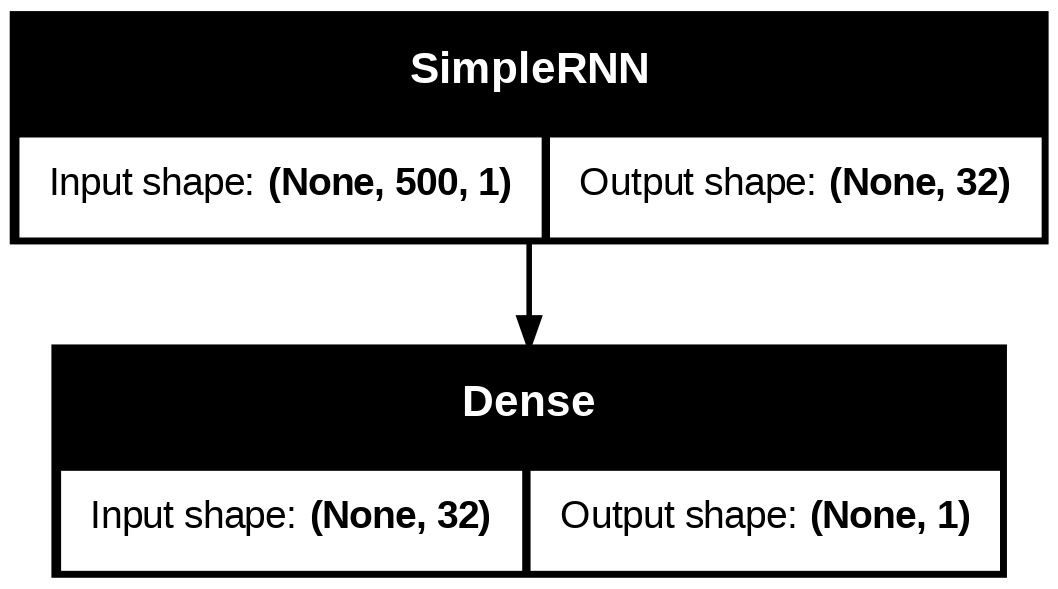

In [20]:
from keras.utils import plot_model

plot_model(model,show_shapes=True)

In [21]:
callback = EarlyStopping(
    monitor='val_loss', # watches validation loss each epoch
    verbose=1,
    patience=3,             
    restore_best_weights=True  # rolls back to the best epoch's weights when it stops
)

In [22]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X_train,y_train,epochs=5,validation_split=0.2)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 58s 57ms/step - accuracy: 0.4992 - loss: 0.6945 - val_accuracy: 0.5059 - val_loss: 0.6935
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.5032 - loss: 0.6946 - val_accuracy: 0.5121 - val_loss: 0.6931
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 56ms/step - accuracy: 0.5077 - loss: 0.6941 - val_accuracy: 0.5027 - val_loss: 0.6935
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.5006 - loss: 0.6939 - val_accuracy: 0.5074 - val_loss: 0.6928
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 57s 57ms/step - accuracy: 0.5051 - loss: 0.6939 - val_accuracy: 0.5041 - val_loss: 0.6934


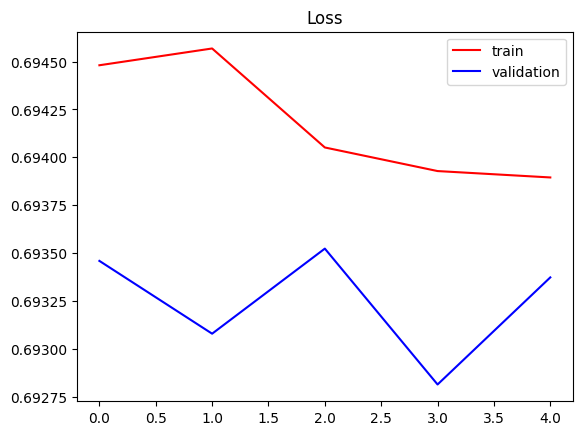

In [23]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

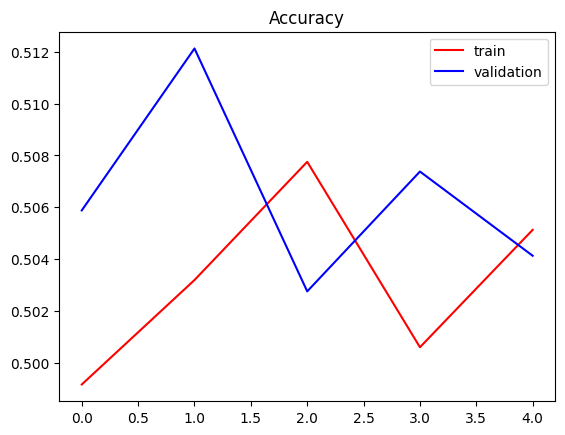

In [24]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()